In [ ]:
!pip install pandas torch transformers scikit-learn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving updated_amazon (1).xlsx to updated_amazon (1).xlsx
Saving final reddit.csv to final reddit.csv
Saving instagram sentiment dataset.csv to instagram sentiment dataset.csv


In [ ]:
import pandas as pd

reddit = pd.read_csv("final reddit.csv")
amazon = pd.read_excel("updated_amazon (1).xlsx")
instagram = pd.read_csv("instagram sentiment dataset.csv")

In [ ]:
reddit.rename(columns={'clean_text':'text'}, inplace=True)
amazon.rename(columns={'clean_text':'text'}, inplace=True)
instagram.rename(columns={'clean_comment':'text'}, inplace=True)

In [ ]:
reddit['platform'] = 'reddit'
amazon['platform'] = 'amazon'
instagram['platform'] = 'instagram'

In [ ]:
df = pd.concat([reddit, amazon, instagram], ignore_index=True)
df = df[['text', 'sentiment', 'platform']]

df.dropna(inplace=True)
df['sentiment'] = df['sentiment'].astype(int)

In [ ]:
print(df['sentiment'].value_counts())

sentiment
1    81950
0    46726
Name: count, dtype: int64


In [ ]:
platform_map = {'reddit':0, 'amazon':1, 'instagram':2}
df['platform_id'] = df['platform'].map(platform_map)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['sentiment'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['sentiment'], random_state=42)

In [ ]:
from transformers import RobertaTokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch
from torch.utils.data import Dataset

class MultiDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, 'text'])
        label = int(self.df.loc[idx, 'sentiment'])
        platform = int(self.df.loc[idx, 'platform_id'])

        encoding = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=80,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'platform': torch.tensor(platform),
            'label': torch.tensor(label)
        }

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(MultiDataset(train_df), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(MultiDataset(val_df), batch_size=32, num_workers=2)
test_loader = DataLoader(MultiDataset(test_df), batch_size=32, num_workers=2)

In [ ]:
import torch.nn as nn
from transformers import RobertaModel

class CrossPlatformModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.text_model = RobertaModel.from_pretrained('roberta-base')

        # Unfreeze last 3 layers
        for name, param in self.text_model.named_parameters():
            if any(layer in name for layer in ["encoder.layer.9","encoder.layer.10","encoder.layer.11"]):
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.platform_embed = nn.Embedding(3, 32)

        self.classifier = nn.Sequential(
            nn.Linear(768 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, platform):
        text_out = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_out.last_hidden_state[:, 0, :]

        platform_feat = self.platform_embed(platform)

        combined = torch.cat((text_feat, platform_feat), dim=1)
        return self.classifier(combined)

In [ ]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from torch.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrossPlatformModel().to(device)

weights = compute_class_weight('balanced', classes=np.unique(df['sentiment']), y=df['sentiment'])
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

scaler = GradScaler()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
train_losses = []
val_losses = []

for epoch in range(5):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        platform = batch['platform'].to(device)
        labels = batch['label'].to(device)

        with autocast(device_type='cuda'):
            outputs = model(input_ids, attention_mask, platform)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            platform = batch['platform'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, platform)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

Epoch 1 | Train: 0.4315 | Val: 0.4269
Epoch 2 | Train: 0.4200 | Val: 0.4261
Epoch 3 | Train: 0.4080 | Val: 0.4207
Epoch 4 | Train: 0.3963 | Val: 0.4229
Epoch 5 | Train: 0.3848 | Val: 0.4285


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()
preds, labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        platform = batch['platform'].to(device)
        label = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, platform)
        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        labels.extend(label.cpu().numpy())

acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds)
rec = recall_score(labels, preds)
f1 = f1_score(labels, preds)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Accuracy: 0.7958501709667392
Precision: 0.9054762598310515
Recall: 0.7586333129957291
F1: 0.8255759909700551


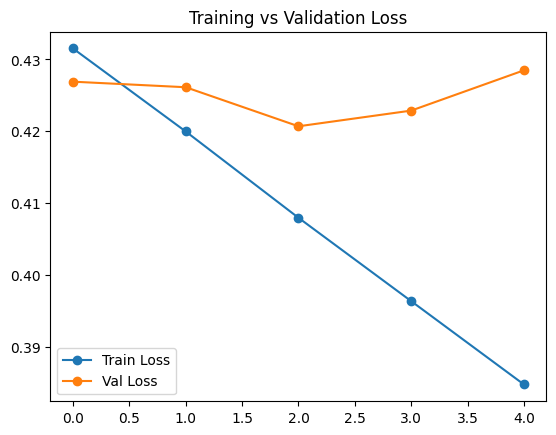

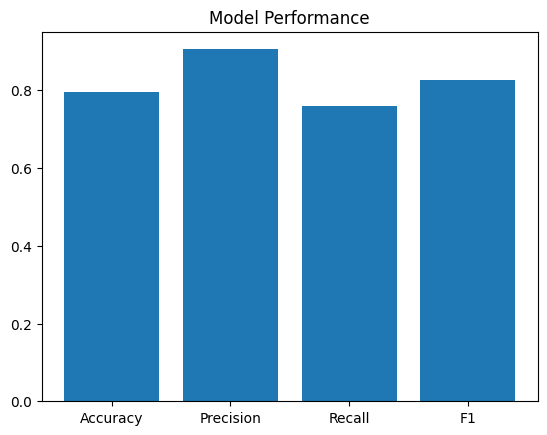

In [ ]:
import matplotlib.pyplot as plt

# Loss Graph
plt.figure()
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Metrics Graph
metrics = [acc, prec, rec, f1]
names = ["Accuracy", "Precision", "Recall", "F1"]

plt.figure()
plt.bar(names, metrics)
plt.title("Model Performance")
plt.show()

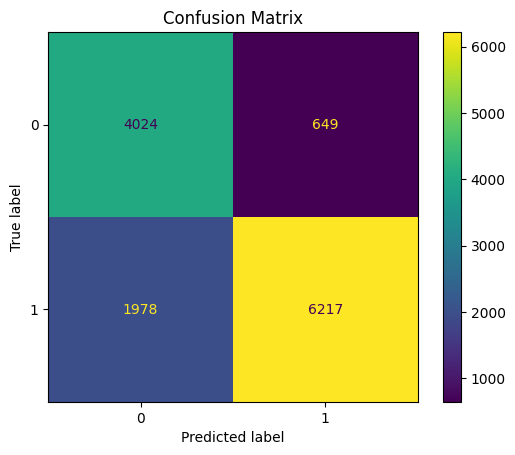

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(labels, preds)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()